In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv('../data/container_usage.csv')

In [3]:
df["time_stamp"] = pd.to_datetime(df["time_stamp"], unit="s")
df.head()

,container_id,machine_id,time_stamp,cpu_util_percent,mem_util_percent,cpi,mem_gps,mpki,net_in,net_out,disk_io_percent
0,NaN,m_108,1970-01-09 01:25:30,20.0,56,NaN,NaN,NaN,0.0,0.0,2.0
1,NaN,m_108,1970-01-09 02:02:50,14.0,64,1.56,0.00,0.0,0.0,0.0,4.0
2,NaN,m_108,1970-01-09 02:03:40,12.0,64,1.46,0.03,0.0,0.0,0.0,4.0
3,NaN,m_108,1970-01-09 02:04:30,10.0,64,1.74,0.00,0.0,0.0,0.0,5.0
4,NaN,m_108,1970-01-09 02:22:20,7.0,65,1.57,0.02,0.0,0.0,0.0,6.0


In [4]:
print(df["container_id"].isnull().sum())
print(df["container_id"].notnull().sum())
print(df["container_id"].nunique())

3503
31666497
33519


In [5]:
df_clean = df.dropna(subset=["container_id"])

In [6]:
container_counts = df["container_id"].value_counts().reset_index()
container_counts.columns = ["container_id", "row_count"]
container_counts

,container_id,row_count
0,c_30063,1167
1,c_21977,1156
2,c_26015,1156
3,c_26395,1155
4,c_35563,1152
...,...,...
33514,c_33642,45
33515,c_29356,42
33516,c_25422,37
33517,c_21430,5


In [7]:
stats = df.groupby("container_id")["cpu_util_percent"].agg([
    "mean",
    "std",
    "min",
    "max"
]).reset_index()

stats["cv"] = stats["std"] / stats["mean"]

In [8]:
low_threshold = stats["cv"].quantile(0.33)
high_threshold = stats["cv"].quantile(0.66)

def label(cv):
    if cv <= low_threshold:
        return "stable"
    elif cv >= high_threshold:
        return "spiky"
    else:
        return "medium"

stats["type"] = stats["cv"].apply(label)

In [9]:
row_counts = df.groupby("container_id").size().reset_index(name="total_rows")

stats = stats.merge(row_counts, on="container_id", how="left")

In [10]:
stats_sorted = stats.sort_values("total_rows", ascending=False)
stats_sorted[["container_id", "total_rows", "mean", "std", "cv", "type"]]

,container_id,total_rows,mean,std,cv,type
21105,c_30063,1167,10.995716,2.248495,0.204488,stable
16841,c_26015,1156,1.189446,0.884455,0.743586,spiky
12598,c_21977,1156,9.227509,7.451962,0.807581,spiky
17241,c_26395,1155,8.550649,2.564554,0.299925,stable
26852,c_35563,1152,2.921875,1.165299,0.398819,medium
...,...,...,...,...,...,...
24857,c_33642,45,48.400000,9.355115,0.193288,stable
20364,c_29356,42,12.261905,4.585553,0.373967,medium
16219,c_25422,37,1.972973,1.040472,0.527363,spiky
12019,c_21430,5,14.200000,1.923538,0.135460,stable


In [11]:
high_quality_count = stats[stats["total_rows"] >= 1100].shape[0]
usable_count = stats[stats["total_rows"] >= 200].shape[0]
unusable_count = stats[stats["total_rows"] < 200].shape[0]
print(high_quality_count)
print(usable_count)
print(unusable_count)

511
32970
549


In [12]:
df_hq = stats[stats["total_rows"] >= 1100]
summary = df_hq["type"].value_counts().reset_index()
summary.columns = ["pattern_type", "count"]
summary["percentage"] = (summary["count"] / summary["count"].sum()) * 100
summary

,pattern_type,count,percentage
0,medium,175,34.246575
1,spiky,169,33.072407
2,stable,167,32.681018


In [13]:
bad_containers = df_hq[
    (df_hq["mean"] == 0) |
    (df_hq["std"] == 0) |
    (df_hq["cv"].isna())
]

In [14]:
clean_selected = df_hq.drop(bad_containers.index)
clean_selected.head()

,container_id,mean,std,min,max,cv,type,total_rows
35,c_10032,2.679211,1.270979,1.0,21.0,0.474386,medium,1116
37,c_10034,12.089350,6.673719,2.0,43.0,0.552033,spiky,1108
95,c_10089,9.589029,2.968964,4.0,20.0,0.309621,stable,1112
141,c_10132,2.958484,1.130225,2.0,10.0,0.382028,medium,1108
169,c_1016,2.274423,1.255814,1.0,28.0,0.552146,spiky,1126


In [15]:
container_ids = clean_selected["container_id"].tolist()

In [16]:
df_final = df_clean[df_clean["container_id"].isin(container_ids)]
df_final.head()

,container_id,machine_id,time_stamp,cpu_util_percent,mem_util_percent,cpi,mem_gps,mpki,net_in,net_out,disk_io_percent
36094,c_10032,m_34,1970-01-02 00:03:20,1.0,19,NaN,NaN,NaN,0.01,0.01,2.0
36095,c_10032,m_34,1970-01-02 00:22:10,2.0,19,NaN,NaN,NaN,0.01,0.01,9.0
36096,c_10032,m_34,1970-01-02 00:52:30,1.0,19,NaN,NaN,NaN,0.01,0.01,NaN
36097,c_10032,m_34,1970-01-02 00:53:30,1.0,19,NaN,NaN,NaN,0.01,0.01,3.0
36098,c_10032,m_34,1970-01-02 00:55:30,1.0,19,NaN,NaN,NaN,0.01,0.01,4.0


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


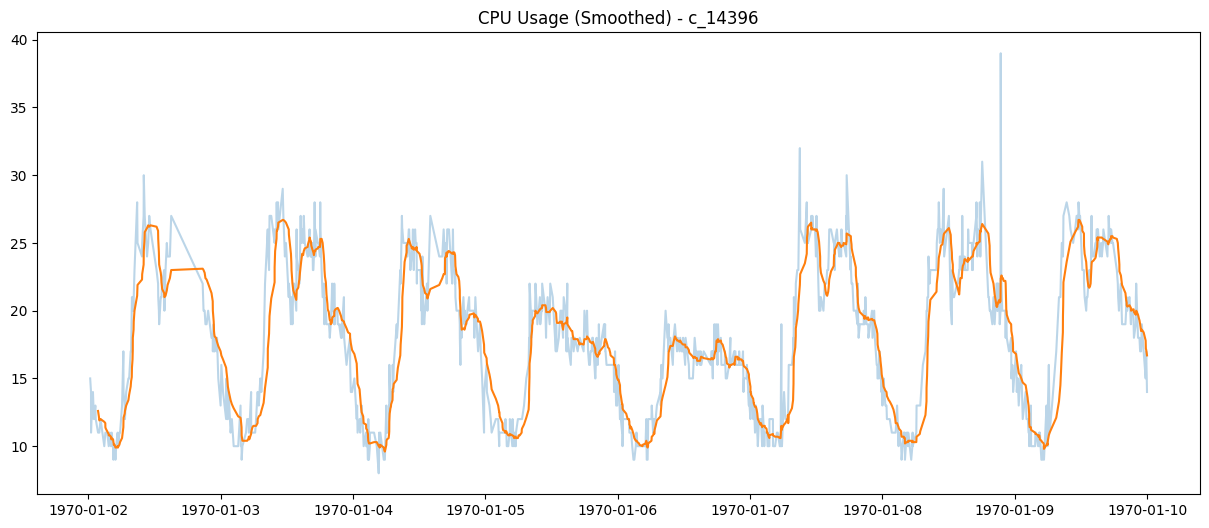

In [58]:
container_id = "c_14396"

df[df["container_id"] == container_id]

df_c = df[df["container_id"] == container_id].copy()
df_c = df_c.sort_values("time_stamp")

df_c["cpu_smooth"] = df_c["cpu_util_percent"].rolling(window=10).mean()

df_c

plt.figure(figsize=(15, 6))
plt.plot(df_c["time_stamp"], df_c["cpu_util_percent"], alpha=0.3)
plt.plot(df_c["time_stamp"], df_c["cpu_smooth"])
plt.title(f"CPU Usage (Smoothed) - {container_id}")
plt.show()

In [18]:
df_final = df_final.sort_values(["container_id", "time_stamp"])

Resampling

In [45]:
FREQ = "15min"

cpu_resampled = (
    df_final
    .set_index("time_stamp")
    .groupby("container_id")["cpu_util_percent"]
    .resample(FREQ)
    .mean()
    .reset_index()
)

In [46]:
cpu_resampled[df_resampled["container_id"] == container_id].head()

,container_id,time_stamp,cpu_util_percent
1535,c_10089,1970-01-02 00:00:00,8.0
1536,c_10089,1970-01-02 00:15:00,7.5
1537,c_10089,1970-01-02 00:30:00,6.0
1538,c_10089,1970-01-02 00:45:00,7.5
1539,c_10089,1970-01-02 01:00:00,NaN


Interpolation

In [48]:
cpu_resampled["cpu_usage"] = (
    cpu_resampled
    .groupby("container_id")["cpu_util_percent"]
    .transform(lambda x: x.interpolate())
)

In [49]:
cpu_resampled[cpu_resampled["container_id"] == container_id].head()

,container_id,time_stamp,cpu_util_percent,cpu_usage
1535,c_10089,1970-01-02 00:00:00,8.0,8.00
1536,c_10089,1970-01-02 00:15:00,7.5,7.50
1537,c_10089,1970-01-02 00:30:00,6.0,6.00
1538,c_10089,1970-01-02 00:45:00,7.5,7.50
1539,c_10089,1970-01-02 01:00:00,NaN,6.75


In [50]:
other_cols = df_final.drop(
    columns=["cpu_util_percent"]
)

In [51]:
df_resampled = pd.merge(
    cpu_resampled,
    other_cols,
    on=["container_id", "time_stamp"],
    how="left"
)

In [55]:
df_resampled.head()

,container_id,time_stamp,cpu_util_percent,cpu_usage,machine_id,mem_util_percent,cpi,mem_gps,mpki,net_in,net_out,disk_io_percent
0,c_10032,1970-01-02 00:00:00,1.00,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,c_10032,1970-01-02 00:15:00,2.00,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,c_10032,1970-01-02 00:30:00,NaN,1.625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,c_10032,1970-01-02 00:45:00,1.25,1.250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,c_10032,1970-01-02 01:00:00,1.00,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Min-Max Normalisation

In [23]:
from sklearn.preprocessing import MinMaxScaler

train_list = []
val_list = []
scalers = {}

for cid, group in df_resampled.groupby("container_id"):
    group = group.sort_values("time_stamp").copy()

    if len(group) < 200:
        continue

    # Use the interpolated column
    group['cpu'] = group['cpu_usage']

    # ------------------- Temporal Split -------------------
    split_idx = int(len(group) * 0.8)
    train_part = group.iloc[:split_idx].copy()
    val_part = group.iloc[split_idx:].copy()

    # ------------------- Normalization -------------------
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_part['cpu_scaled'] = scaler.fit_transform(train_part[['cpu']])
    val_part['cpu_scaled']   = scaler.transform(val_part[['cpu']])

    scalers[cid] = scaler

    # ------------------- Statistics ONLY from TRAIN -------------------
    cpu_mean = train_part['cpu_scaled'].mean()
    cpu_std  = train_part['cpu_scaled'].std()
    cpu_max  = train_part['cpu_scaled'].max()
    cpu_min  = train_part['cpu_scaled'].min()

    # Add stats to both train and val
    for part in [train_part, val_part]:
        part['cpu_mean'] = cpu_mean
        part['cpu_std']  = cpu_std
        part['cpu_max']  = cpu_max
        part['cpu_min']  = cpu_min
        part['hour']     = part['time_stamp'].dt.hour

    train_list.append(train_part)
    val_list.append(val_part)


train_df = pd.concat(train_list, ignore_index=True)
val_df = pd.concat(val_list, ignore_index=True)

print("Preprocessing Done!")
print(f"Train samples : {len(train_df)}")
print(f"Val samples   : {len(val_df)}")
print(f"Containers    : {len(scalers)}")

Preprocessing Done!
Train samples : 297804
Val samples   : 74736
Containers    : 486


In [59]:
train_df["container_id"].nunique(), val_df["container_id"].nunique()

(486, 486)

In [60]:
train_c = train_df[train_df["container_id"] == container_id]
val_c   = val_df[val_df["container_id"] == container_id]

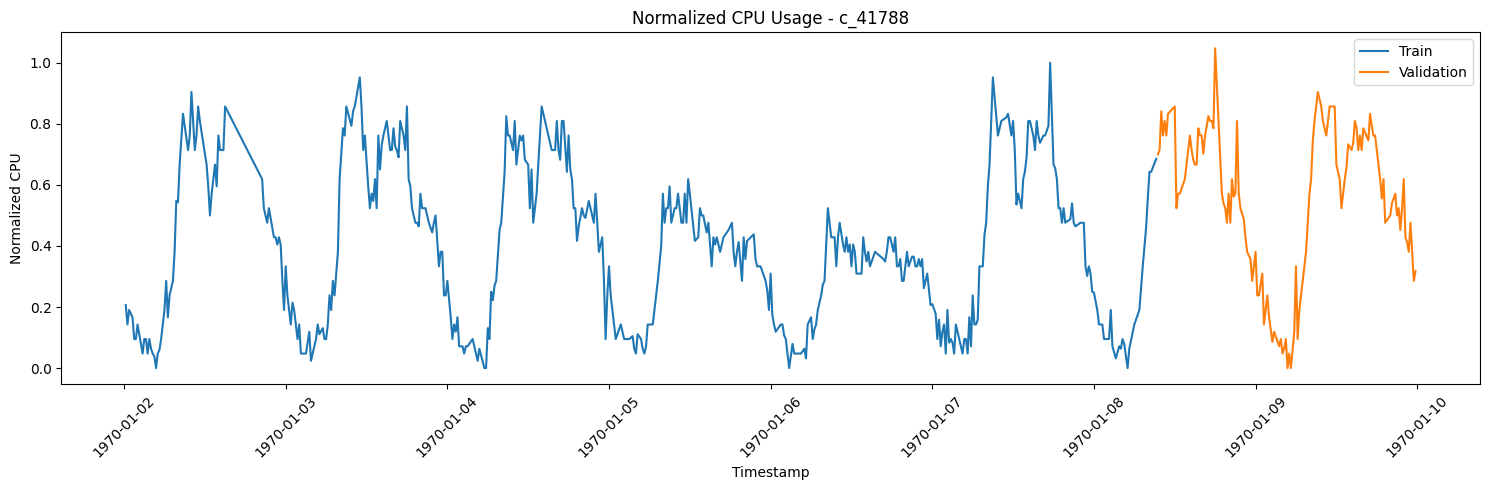

In [61]:
plt.figure(figsize=(15, 5))

# Train
plt.plot(train_c["time_stamp"], train_c["cpu_scaled"], label="Train")

# Validation
plt.plot(val_c["time_stamp"], val_c["cpu_scaled"], label="Validation")

plt.xlabel("Timestamp")
plt.ylabel("Normalized CPU")
plt.title(f"Normalized CPU Usage - {cid}")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

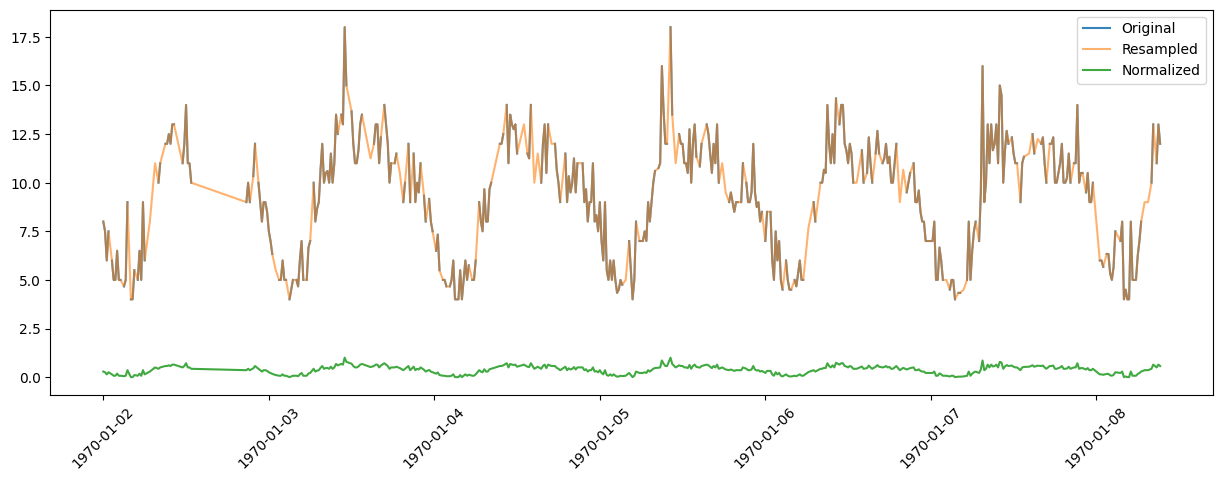

In [27]:
plt.figure(figsize=(15,5))

plt.plot(train_c["time_stamp"], train_c["cpu_util_percent"], label="Original", alpha=0.9)
plt.plot(train_c["time_stamp"], train_c["cpu_usage"], label="Resampled", alpha=0.6)
plt.plot(train_c["time_stamp"], train_c["cpu_scaled"], label="Normalized", alpha=0.9)

plt.legend()
plt.xticks(rotation=45)
plt.show()

In [28]:
train_df.to_parquet(
    "../data/train_df.parquet"
)

In [29]:
val_df.to_parquet(
    "../data/val_df.parquet"
)

In [56]:
df_resampled.to_parquet(
    "../data/df_resampled.parquet"
)